In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## 1.Exploratory Data Analysis (EDA):

In [41]:
# Load the dataset
training  =pd.read_csv("Titanic_train.csv")
testing  = pd.read_csv("Titanic_test.csv")

In [42]:
training.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [43]:
testing .head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [44]:
training.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [45]:
testing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [46]:
# checking for missing values
training.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [47]:
testing.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [48]:
# handle missing values: 
median_age=training['Age'].median()
training['Age'].fillna(median_age,inplace=True)
    # fill the missing values of testing dataset with median of training dataset
testing['Age'].fillna(median_age,inplace=True)

/var/folders/hf/bzjj7rqn5bb5pbw837t8l1080000gn/T/ipykernel_32522/3135011271.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  training['Age'].fillna(median_age,inplace=True)
/var/folders/hf/bzjj7rqn5bb5pbw837t8l1080000gn/T/ipykernel_32522/3135011271.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

In [49]:
training.drop(columns=['Cabin'], inplace=True)
testing.drop(columns=['Cabin'], inplace=True)

In [50]:
mode_embarked = training['Embarked'].mode()[0]
training['Embarked'].fillna(mode_embarked, inplace=True)
    # fill the missing values of testing dataset with median of training dataset

testing['Embarked'].fillna(mode_embarked, inplace=True)

/var/folders/hf/bzjj7rqn5bb5pbw837t8l1080000gn/T/ipykernel_32522/4218692385.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  training['Embarked'].fillna(mode_embarked, inplace=True)
/var/folders/hf/bzjj7rqn5bb5pbw837t8l1080000gn/T/ipykernel_32522/4218692385.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

In [51]:
training.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [52]:
testing.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
dtype: int64

In [53]:
median_fare=training['Fare'].median()
testing['Fare'].fillna(median_fare,inplace=True)

/var/folders/hf/bzjj7rqn5bb5pbw837t8l1080000gn/T/ipykernel_32522/803973656.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  testing['Fare'].fillna(median_fare,inplace=True)


In [54]:
testing.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [55]:
testing.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


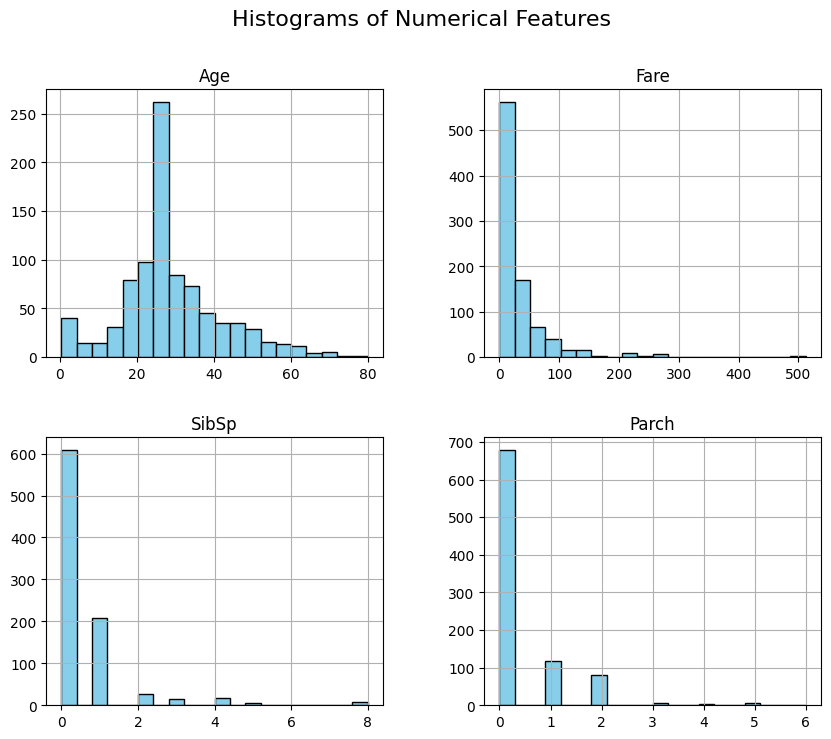

In [56]:
# Visualize:
    # histogram
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
training[numeric_cols].hist(bins=20, figsize=(10, 8), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.show()

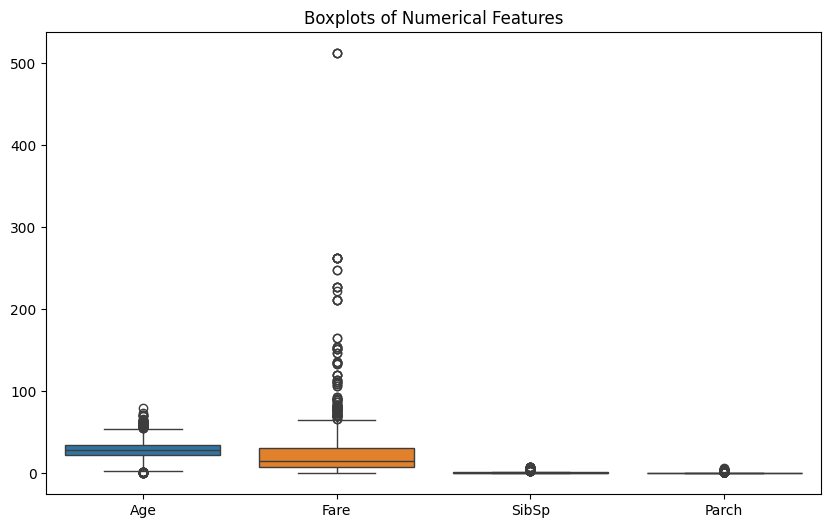

In [57]:
    # boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=training[numeric_cols])
plt.title('Boxplots of Numerical Features')
plt.show()

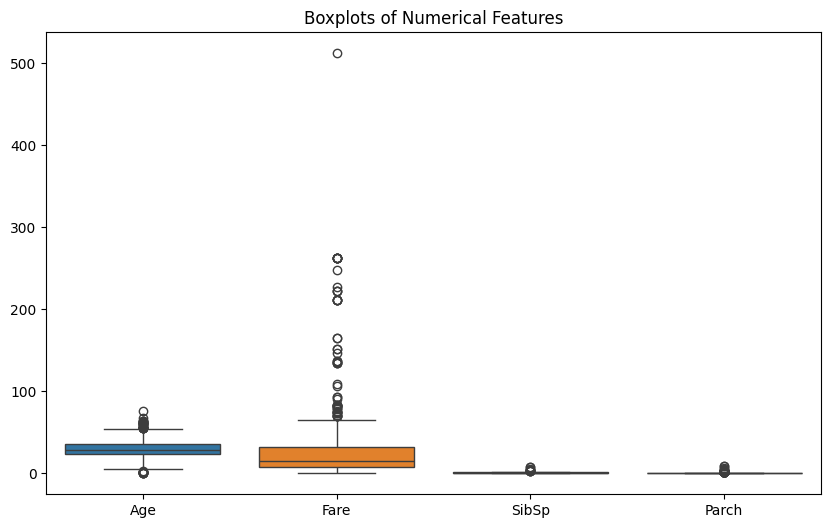

In [58]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=testing[numeric_cols])
plt.title('Boxplots of Numerical Features')
plt.show()

In [61]:
# handle outliers: 

# Select numeric columns
num_cols = testing.select_dtypes(include=['int64','float64']).columns

# --- Outlier detection and treatment on TRAIN, apply same on TEST ---
for col in num_cols:
    Q1 = training[col].quantile(0.25)
    Q3 = training[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Cap (clip) values in TRAIN
    training[col] = training[col].clip(lower, upper)

    # Cap (clip) values in TEST using same limits
    testing[col] = testing[col].clip(lower, upper)

print("Outliers treated successfully for both Train and Test datasets.")


Outliers treated successfully for both Train and Test datasets.


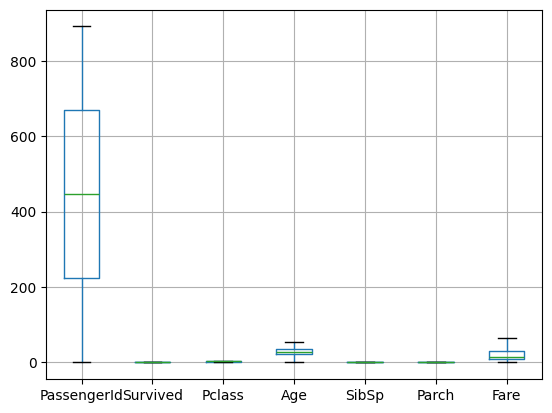

In [62]:
training.boxplot()
plt.show()

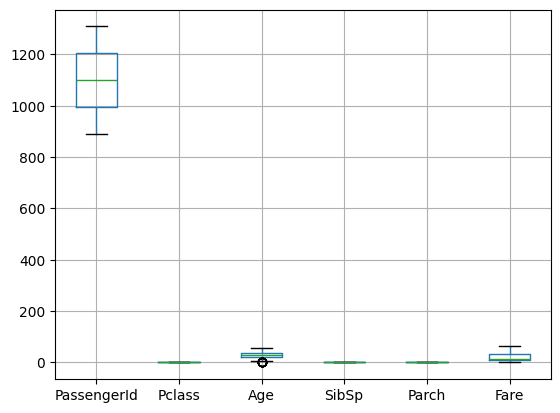

In [63]:
testing.boxplot()
plt.show()

/var/folders/hf/bzjj7rqn5bb5pbw837t8l1080000gn/T/ipykernel_32522/460491583.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Survived', data=training, palette='coolwarm', estimator=lambda x: sum(x)/len(x))


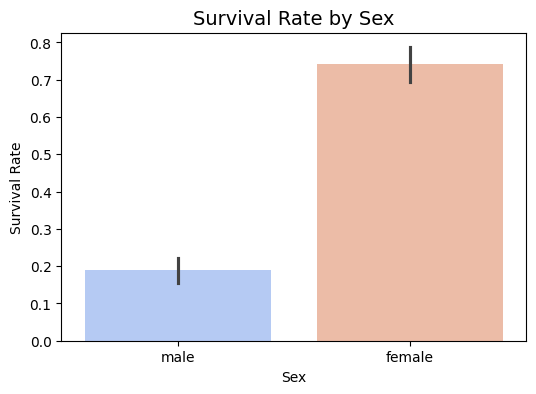

/var/folders/hf/bzjj7rqn5bb5pbw837t8l1080000gn/T/ipykernel_32522/460491583.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Survived', data=training, palette='coolwarm', estimator=lambda x: sum(x)/len(x))


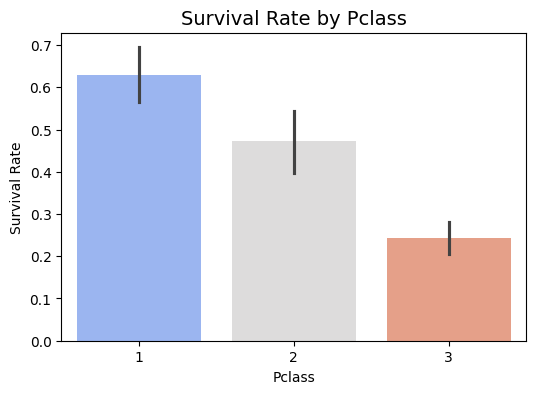

/var/folders/hf/bzjj7rqn5bb5pbw837t8l1080000gn/T/ipykernel_32522/460491583.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Survived', data=training, palette='coolwarm', estimator=lambda x: sum(x)/len(x))


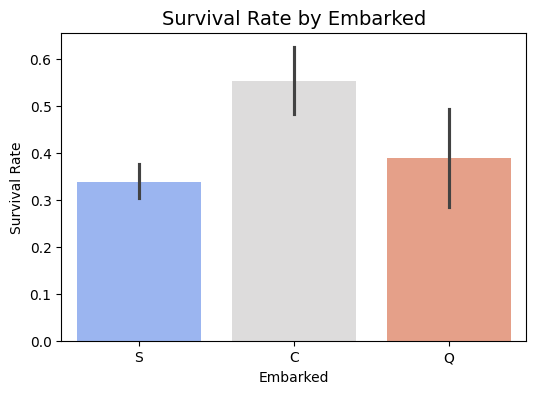

In [64]:
categorical_cols = ['Sex', 'Pclass', 'Embarked']
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(x=col, y='Survived', data=training, palette='coolwarm', estimator=lambda x: sum(x)/len(x))
    plt.title(f'Survival Rate by {col}', fontsize=14)
    plt.ylabel('Survival Rate')
    plt.show()

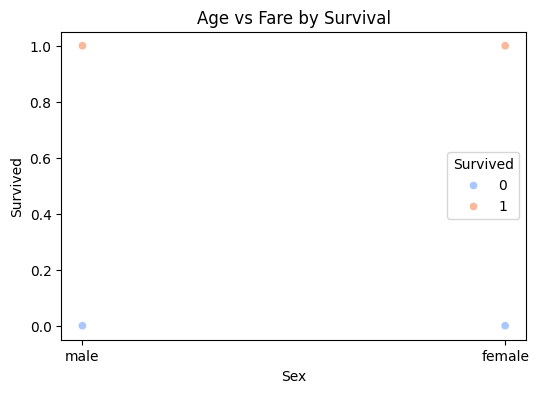

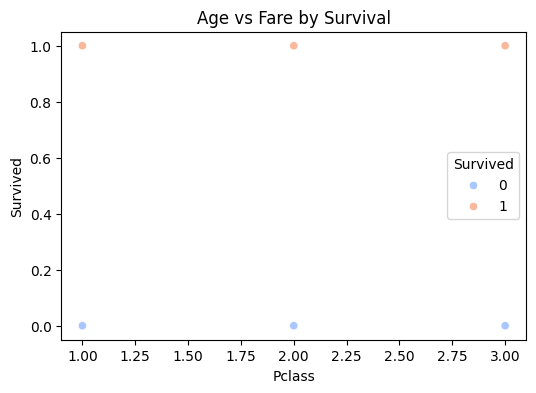

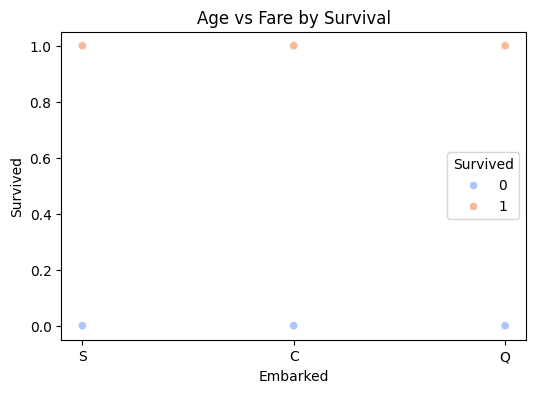

In [65]:
categorical_cols = ['Sex', 'Pclass', 'Embarked']
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=col, y='Survived', hue='Survived', data=training, palette='coolwarm')
    plt.title('Age vs Fare by Survival')
    plt.show()

## Data Preprocessing:

In [68]:
# already done with handling missing values

In [69]:
training.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             65
SibSp            4
Parch            1
Ticket         681
Fare           204
Embarked         3
dtype: int64

In [70]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
training['Sex'] = le.fit_transform(training['Sex'])
testing['Sex'] = le.transform(testing['Sex'])

In [71]:
categorical_cols = ['Pclass', 'Embarked']
training = pd.get_dummies(training, columns=categorical_cols, drop_first=True)
testing = pd.get_dummies(testing, columns=categorical_cols, drop_first=True)

In [72]:
training.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
testing.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [73]:
training.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Embarked_Q,Embarked_S
0,0,1,22.0,1.0,0,7.2500,False,True,False,True
1,1,0,38.0,1.0,0,65.6344,False,False,False,False
2,1,0,26.0,0.0,0,7.9250,False,True,False,True
3,1,0,35.0,1.0,0,53.1000,False,False,False,True
4,0,1,35.0,0.0,0,8.0500,False,True,False,True


In [74]:
testing.head()

,Sex,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Embarked_Q,Embarked_S
0,1,34.5,0.0,0,7.8292,False,True,True,False
1,0,47.0,1.0,0,7.0000,False,True,False,True
2,1,54.5,0.0,0,9.6875,True,False,True,False
3,1,27.0,0.0,0,8.6625,False,True,False,True
4,0,22.0,1.0,0,12.2875,False,True,False,True


## Building Predictive Models:

In [75]:
# Target variable
y=training['Survived']

x=training.drop('Survived',axis=1)

In [78]:
# split the dataset into train and validation
from sklearn.model_selection import train_test_split

x_train,x_valid,y_train,y_valid=train_test_split(x,y,test_size=0.2,random_state=42)

In [79]:
print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_valid.shape, y_valid.shape)

Training set: (712, 9) (712,)
Validation set: (179, 9) (179,)


In [80]:
import lightgbm as lgb
lgb=lgb.LGBMClassifier(n_estimators=100,learning_rate=0.5,min_child_weight=2,reg_alpha=5,reg_lambda=10,subsample=0.9,max_depth=3,max_features=1,random_state=50,max_bin=10)

In [89]:
# train the model:
lgb.fit(x_train,y_train)
# predict the model:
y_pred_lgb=lgb.predict(x_valid)
# evaluate the model
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

print("Accuracy:", accuracy_score(y_valid, y_pred_lgb))
print("Precision:", precision_score(y_valid, y_pred_lgb))
print("Recall:", recall_score(y_valid, y_pred_lgb))
print("F1-Score:", f1_score(y_valid, y_pred_lgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_valid, y_pred_lgb))
print("\nClassification Report:\n", classification_report(y_valid, y_pred_lgb))

[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000382 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 34
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

In [88]:
import xgboost as xgb
# load model
xgb=xgb.XGBClassifier(n_estimators=100,learning_rate=0.5,min_child_weight=2,reg_alpha=5,reg_lambda=10,subsample=0.9,max_depth=3,max_features=1,random_state=50)

# train the model
xgb.fit(x_train, y_train)

# predictions
y_pred_xgb = xgb.predict(x_valid)

# evalate the trained model
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

print("=== XGBoost Evaluation ===")
print("Accuracy:", accuracy_score(y_valid, y_pred_xgb))
print("Precision:", precision_score(y_valid, y_pred_xgb))
print("Recall:", recall_score(y_valid, y_pred_xgb))
print("F1-Score:", f1_score(y_valid, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_valid, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_valid, y_pred_xgb))

=== XGBoost Evaluation ===
Accuracy: 0.7932960893854749
Precision: 0.7936507936507936
Recall: 0.6756756756756757
F1-Score: 0.7299270072992701

Confusion Matrix:
 [[92 13]
 [24 50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83       105
           1       0.79      0.68      0.73        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [01:34:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [90]:
# Build predictive models using LightGBM and XGBoost algorithms.

test_predictions_lgb = lgb.predict(testing)
test_predictions_xgb = xgb.predict(testing)

[LightGBM] [Warning] Unknown parameter: max_features


In [93]:
# Cross-validation 

from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lgb, x_train, y_train, cv=5, scoring='f1')
print("LightGBM 5-fold F1-scores:", cv_scores)
print("Mean F1-score:", cv_scores.mean())

[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Info] Number of positive: 214, number of negative: 355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000661 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 34
[LightGBM] [Info] Number of data points in the train set: 569, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376098 -> initscore=-0.506142
[LightGBM] [Info] Start training from score -0.506142
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

In [94]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5],
    'max_depth': [3, 5, 7]
}
grid_search = GridSearchCV(
    estimator=lgb,
    param_grid=param_grid,
    scoring='f1',  
    cv=3,
    verbose=1
)
grid_search.fit(x_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best F1-score:", grid_search.best_score_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Info] Number of positive: 178, number of negative: 296
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 34
[LightGBM] [Info] Number of data points in the train set: 474, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375527 -> initscore=-0.508576
[LightGBM] [Info] Start training from score -0.508576
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

## Comparative Analysis:

In [96]:
metrics = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'LightGBM': [
        accuracy_score(y_valid, y_pred_lgb),
        precision_score(y_valid, y_pred_lgb),
        recall_score(y_valid, y_pred_lgb),
        f1_score(y_valid, y_pred_lgb)
    ],
    'XGBoost': [
        accuracy_score(y_valid, y_pred_xgb),
        precision_score(y_valid, y_pred_xgb),
        recall_score(y_valid, y_pred_xgb),
        f1_score(y_valid, y_pred_xgb)
    ]
}
import pandas as pd
comparison_df = pd.DataFrame(metrics)
print(comparison_df)

      Metric  LightGBM   XGBoost
0   Accuracy  0.810056  0.793296
1  Precision  0.812500  0.793651
2     Recall  0.702703  0.675676
3   F1-Score  0.753623  0.729927


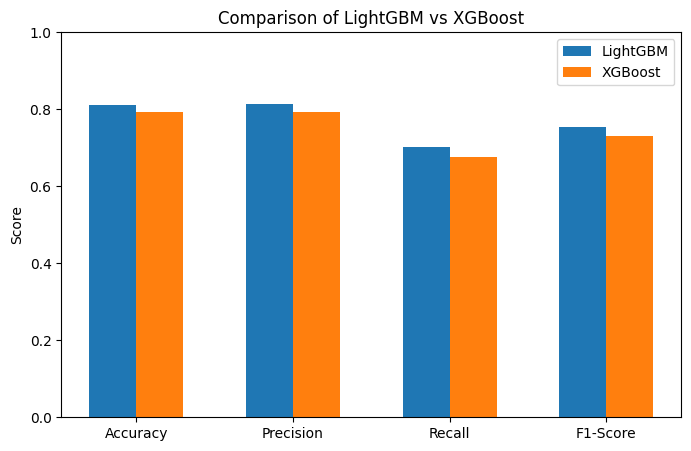

In [97]:
plt.figure(figsize=(8,5))
x = range(len(metrics['Metric']))
plt.bar([i-0.15 for i in x], metrics['LightGBM'], width=0.3, label='LightGBM')
plt.bar([i+0.15 for i in x], metrics['XGBoost'], width=0.3, label='XGBoost')
plt.xticks(x, metrics['Metric'])
plt.ylabel('Score')
plt.title('Comparison of LightGBM vs XGBoost')
plt.ylim(0,1)
plt.legend()
plt.show()

LightGBM outperformed XGBoost in accuracy, precision, recall, and F1-score, indicating better predictive capability and class detection in this dataset. While XGBoost remains stable and reliable, LightGBM’s leaf-wise tree growth and faster training process provided stronger results for this task.